# Final Technical Artefact Synthesis

## Data-Centric AI Safety:
### Evaluating Text Cleaning Techniques for Robust Detection of Disempowerment Patterns in Human-AI Conversations

This notebook consolidates the outputs of the pilot and scaled experiments
without introducing new weak-labelling rules, preprocessing configurations,
noise conditions, model architectures, or training procedures.

The purpose of this notebook is to provide a reproducible technical synthesis
of the completed artefact and to connect the experimental outputs to the three
research questions.

### Frozen experimental components

The final synthesis uses the previously frozen components:

- relevance filtering: `relevance_v1`
- weak labelling: `disempowerment_weak_v5`
- synthetic noise: `noise_v1`
- preprocessing: `preprocess_v1`
- baseline model: TF-IDF word unigrams/bigrams + LinearSVC
- source-level cross-validation with deterministic random seed `42`

### Research questions

**RQ1.** How do text cleaning and preprocessing strategies affect the
robustness of NLP classifiers for detecting disempowerment patterns in noisy
human-AI conversations?

**RQ2.** Which textual noise types and preprocessing configurations produce
the greatest changes in classifier performance across clean, noisy, and
cleaned-noisy conversation data?

**RQ3.** How do preprocessing choices influence the preservation or loss of
linguistic cues associated with disempowerment, including sycophantic
validation, overconfident judgement, and directive advice?

### Scope

This notebook performs synthesis only. It reads previously generated result
tables and figures from the repository and does not retrain models or modify
the frozen experimental pipeline.

In [1]:
# ------------------------------------------------------------
# Final synthesis — restore project paths and inventory results
# ------------------------------------------------------------

from pathlib import Path

import pandas as pd
import numpy as np


PROJECT_ROOT = Path(
    "/workspaces/irp-disempowerment-nlp"
)

RESULTS_TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)


assert PROJECT_ROOT.exists()
assert RESULTS_TABLE_DIR.exists()
assert RESULTS_FIGURE_DIR.exists()


pilot_tables = sorted(
    path.name
    for path in RESULTS_TABLE_DIR.glob(
        "pilot_*.csv"
    )
)

scaled_tables = sorted(
    path.name
    for path in RESULTS_TABLE_DIR.glob(
        "scaled_*.csv"
    )
)

pilot_figures = sorted(
    path.name
    for path in RESULTS_FIGURE_DIR.glob(
        "pilot_*.png"
    )
)

scaled_figures = sorted(
    path.name
    for path in RESULTS_FIGURE_DIR.glob(
        "scaled_*.png"
    )
)


print("=" * 80)
print("PILOT RESULT TABLES")
print("=" * 80)

for filename in pilot_tables:
    print(filename)


print("\n" + "=" * 80)
print("SCALED RESULT TABLES")
print("=" * 80)

for filename in scaled_tables:
    print(filename)


print("\n" + "=" * 80)
print("PILOT FIGURES")
print("=" * 80)

for filename in pilot_figures:
    print(filename)


print("\n" + "=" * 80)
print("SCALED FIGURES")
print("=" * 80)

for filename in scaled_figures:
    print(filename)


print("\n" + "=" * 80)
print("INVENTORY COUNTS")
print("=" * 80)

print("Pilot tables:", len(pilot_tables))
print("Scaled tables:", len(scaled_tables))
print("Pilot figures:", len(pilot_figures))
print("Scaled figures:", len(scaled_figures))

print(
    "\nResult inventory completed successfully."
)

PILOT RESULT TABLES
pilot_classification_metrics.csv
pilot_clean_oof_predictions.csv
pilot_fold_ranking_metrics.csv
pilot_positive_source_stability.csv
pilot_ranking_deltas.csv
pilot_ranking_summary.csv
pilot_robustness_oof_predictions.csv
pilot_score_shift_summary.csv
pilot_source_fold_assignments.csv

SCALED RESULT TABLES
scaled_degradation_vs_clean.csv
scaled_directive_cue_retention.csv
scaled_directive_cue_retention_summary.csv
scaled_fold_condition_metrics.csv
scaled_noise_only_sensitivity.csv
scaled_nonaggressive_cue_loss_cases.csv
scaled_nonaggressive_cue_retention_by_noise.csv
scaled_oof_predictions_52256.csv
scaled_positive_score_shifts.csv
scaled_positive_source_stability.csv
scaled_preprocess_effect_summary.csv
scaled_robustness_summary_32_conditions.csv

PILOT FIGURES
pilot_average_precision_robustness.png
pilot_positive_score_shift.png
pilot_roc_auc_robustness.png

SCALED FIGURES
scaled_average_precision_robustness.png
scaled_directive_cue_retention.png
scaled_positive_sco

In [2]:
# ------------------------------------------------------------
# Load key pilot + scaled synthesis tables
# ------------------------------------------------------------

pilot_classification_df = pd.read_csv(
    RESULTS_TABLE_DIR
    / "pilot_classification_metrics.csv"
)

pilot_ranking_df = pd.read_csv(
    RESULTS_TABLE_DIR
    / "pilot_ranking_summary.csv"
)

pilot_score_shift_df = pd.read_csv(
    RESULTS_TABLE_DIR
    / "pilot_score_shift_summary.csv"
)

scaled_robustness_df = pd.read_csv(
    RESULTS_TABLE_DIR
    / "scaled_robustness_summary_32_conditions.csv"
)

scaled_preprocess_effect_df = pd.read_csv(
    RESULTS_TABLE_DIR
    / "scaled_preprocess_effect_summary.csv"
)

scaled_cue_summary_df = pd.read_csv(
    RESULTS_TABLE_DIR
    / "scaled_directive_cue_retention_summary.csv"
)


tables_to_inspect = {
    "pilot_classification_metrics":
        pilot_classification_df,

    "pilot_ranking_summary":
        pilot_ranking_df,

    "pilot_score_shift_summary":
        pilot_score_shift_df,

    "scaled_robustness_summary":
        scaled_robustness_df,

    "scaled_preprocess_effect_summary":
        scaled_preprocess_effect_df,

    "scaled_directive_cue_retention_summary":
        scaled_cue_summary_df,
}


for name, df in tables_to_inspect.items():

    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)

    print(
        "Shape:",
        df.shape,
    )

    print(
        "\nColumns:"
    )

    print(
        df.columns.tolist()
    )

    print(
        "\nFirst rows:"
    )

    print(
        df.head().to_string(
            index=False
        )
    )


print(
    "\nKey synthesis tables loaded successfully."
)


pilot_classification_metrics
Shape: (32, 12)

Columns:
['noise_condition', 'preprocess_config', 'accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp', 'predicted_positive']

First rows:
noise_condition preprocess_config  accuracy  balanced_accuracy  precision  recall  f1  tn  fp  fn  tp  predicted_positive
          clean              none      0.94                0.5        0.0     0.0 0.0  94   0   6   0                   0
          clean           minimal      0.94                0.5        0.0     0.0 0.0  94   0   6   0                   0
          clean       noise_aware      0.94                0.5        0.0     0.0 0.0  94   0   6   0                   0
          clean        aggressive      0.94                0.5        0.0     0.0 0.0  94   0   6   0                   0
         casing              none      0.94                0.5        0.0     0.0 0.0  94   0   6   0                   0

pilot_ranking_summary
Shape: (32, 6)

Columns:
['

In [3]:
# ------------------------------------------------------------
# Pilot vs scaled robustness comparison
# Use mean-fold ranking metrics for comparability
# ------------------------------------------------------------

NON_AGGRESSIVE_CONFIGS = [
    "none",
    "minimal",
    "noise_aware",
]


# ============================================================
# PILOT
# ============================================================

pilot_clean = (
    pilot_ranking_df[
        (
            pilot_ranking_df["noise_condition"] == "clean"
        )
        &
        (
            pilot_ranking_df["preprocess_config"] == "none"
        )
    ]
    .iloc[0]
)


pilot_non_aggressive = (
    pilot_ranking_df[
        pilot_ranking_df[
            "preprocess_config"
        ].isin(NON_AGGRESSIVE_CONFIGS)
    ]
)

pilot_aggressive = (
    pilot_ranking_df[
        pilot_ranking_df[
            "preprocess_config"
        ] == "aggressive"
    ]
)


pilot_nonagg_roc = (
    pilot_non_aggressive[
        "mean_roc_auc"
    ].mean()
)

pilot_nonagg_ap = (
    pilot_non_aggressive[
        "mean_average_precision"
    ].mean()
)

pilot_aggressive_roc = (
    pilot_aggressive[
        "mean_roc_auc"
    ].mean()
)

pilot_aggressive_ap = (
    pilot_aggressive[
        "mean_average_precision"
    ].mean()
)


# ============================================================
# SCALED
# ============================================================

scaled_clean = (
    scaled_robustness_df[
        (
            scaled_robustness_df[
                "noise_condition"
            ] == "clean"
        )
        &
        (
            scaled_robustness_df[
                "preprocess_config"
            ] == "none"
        )
    ]
    .iloc[0]
)


scaled_non_aggressive = (
    scaled_robustness_df[
        scaled_robustness_df[
            "preprocess_config"
        ].isin(NON_AGGRESSIVE_CONFIGS)
    ]
)

scaled_aggressive = (
    scaled_robustness_df[
        scaled_robustness_df[
            "preprocess_config"
        ] == "aggressive"
    ]
)


scaled_nonagg_roc = (
    scaled_non_aggressive[
        "mean_fold_roc_auc"
    ].mean()
)

scaled_nonagg_ap = (
    scaled_non_aggressive[
        "mean_fold_average_precision"
    ].mean()
)

scaled_aggressive_roc = (
    scaled_aggressive[
        "mean_fold_roc_auc"
    ].mean()
)

scaled_aggressive_ap = (
    scaled_aggressive[
        "mean_fold_average_precision"
    ].mean()
)


# ============================================================
# COMPARISON TABLE
# ============================================================

pilot_vs_scaled_df = pd.DataFrame(
    [
        {
            "experiment": "pilot",
            "sources": 100,
            "positives": 6,
            "positive_prevalence_pct": 6.0,

            "clean_mean_fold_roc_auc":
                float(
                    pilot_clean[
                        "mean_roc_auc"
                    ]
                ),

            "clean_mean_fold_ap":
                float(
                    pilot_clean[
                        "mean_average_precision"
                    ]
                ),

            "nonaggressive_mean_roc_auc":
                pilot_nonagg_roc,

            "nonaggressive_mean_ap":
                pilot_nonagg_ap,

            "aggressive_mean_roc_auc":
                pilot_aggressive_roc,

            "aggressive_mean_ap":
                pilot_aggressive_ap,

            "aggressive_roc_delta_vs_nonagg":
                (
                    pilot_aggressive_roc
                    - pilot_nonagg_roc
                ),

            "aggressive_ap_delta_vs_nonagg":
                (
                    pilot_aggressive_ap
                    - pilot_nonagg_ap
                ),

            "aggressive_ap_retention_pct":
                (
                    pilot_aggressive_ap
                    / pilot_nonagg_ap
                    * 100
                ),
        },

        {
            "experiment": "scaled",
            "sources": 1633,
            "positives": 17,
            "positive_prevalence_pct":
                (
                    17 / 1633 * 100
                ),

            "clean_mean_fold_roc_auc":
                float(
                    scaled_clean[
                        "mean_fold_roc_auc"
                    ]
                ),

            "clean_mean_fold_ap":
                float(
                    scaled_clean[
                        "mean_fold_average_precision"
                    ]
                ),

            "nonaggressive_mean_roc_auc":
                scaled_nonagg_roc,

            "nonaggressive_mean_ap":
                scaled_nonagg_ap,

            "aggressive_mean_roc_auc":
                scaled_aggressive_roc,

            "aggressive_mean_ap":
                scaled_aggressive_ap,

            "aggressive_roc_delta_vs_nonagg":
                (
                    scaled_aggressive_roc
                    - scaled_nonagg_roc
                ),

            "aggressive_ap_delta_vs_nonagg":
                (
                    scaled_aggressive_ap
                    - scaled_nonagg_ap
                ),

            "aggressive_ap_retention_pct":
                (
                    scaled_aggressive_ap
                    / scaled_nonagg_ap
                    * 100
                ),
        },
    ]
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display_comparison_df = (
    pilot_vs_scaled_df.copy()
)


numeric_cols = (
    display_comparison_df
    .select_dtypes(
        include="number"
    )
    .columns
)


display_comparison_df[
    numeric_cols
] = (
    display_comparison_df[
        numeric_cols
    ]
    .round(4)
)


print("=" * 115)
print("PILOT VS SCALED ROBUSTNESS COMPARISON")
print("=" * 115)

print(
    display_comparison_df.to_string(
        index=False
    )
)


print(
    "\nNOTE: Average Precision should not be compared "
    "solely by absolute magnitude because positive prevalence "
    "differs substantially between the pilot and scaled experiments."
)

print(
    "Relative degradation/retention under aggressive preprocessing "
    "is therefore particularly informative."
)

PILOT VS SCALED ROBUSTNESS COMPARISON
experiment  sources  positives  positive_prevalence_pct  clean_mean_fold_roc_auc  clean_mean_fold_ap  nonaggressive_mean_roc_auc  nonaggressive_mean_ap  aggressive_mean_roc_auc  aggressive_mean_ap  aggressive_roc_delta_vs_nonagg  aggressive_ap_delta_vs_nonagg  aggressive_ap_retention_pct
     pilot      100          6                    6.000                   0.8670              0.5370                      0.8680                 0.5502                   0.7617              0.4735                         -0.1063                        -0.0767                      86.0583
    scaled     1633         17                    1.041                   0.8729              0.1974                      0.8704                 0.1948                   0.6717              0.0226                         -0.1987                        -0.1722                      11.5981

NOTE: Average Precision should not be compared solely by absolute magnitude because positive p

In [4]:
# ------------------------------------------------------------
# Research-question synthesis table
# ------------------------------------------------------------

scaled_noise_only_df = pd.read_csv(
    RESULTS_TABLE_DIR
    / "scaled_noise_only_sensitivity.csv"
)

scaled_positive_stability_df = pd.read_csv(
    RESULTS_TABLE_DIR
    / "scaled_positive_source_stability.csv"
)

scaled_positive_shifts_df = pd.read_csv(
    RESULTS_TABLE_DIR
    / "scaled_positive_score_shifts.csv"
)


# ------------------------------------------------------------
# Key scaled quantities
# ------------------------------------------------------------

scaled_clean_roc = float(
    scaled_clean[
        "mean_fold_roc_auc"
    ]
)

scaled_clean_ap = float(
    scaled_clean[
        "mean_fold_average_precision"
    ]
)


scaled_aggressive_roc_drop = (
    scaled_aggressive_roc
    - scaled_nonagg_roc
)

scaled_aggressive_ap_retention = (
    scaled_aggressive_ap
    / scaled_nonagg_ap
    * 100
)


noise_none_df = (
    scaled_noise_only_df[
        scaled_noise_only_df[
            "preprocess_config"
        ] == "none"
    ]
    if "preprocess_config"
    in scaled_noise_only_df.columns
    else scaled_noise_only_df.copy()
)


worst_noise_ap_row = (
    noise_none_df[
        noise_none_df[
            "noise_condition"
        ] != "clean"
    ]
    .sort_values(
        "pooled_average_precision"
    )
    .iloc[0]
)


worst_noise_roc_row = (
    noise_none_df[
        noise_none_df[
            "noise_condition"
        ] != "clean"
    ]
    .sort_values(
        "pooled_roc_auc"
    )
    .iloc[0]
)


# Positive score sensitivity.
aggressive_shift_rows = (
    scaled_positive_shifts_df[
        scaled_positive_shifts_df[
            "preprocess_config"
        ] == "aggressive"
    ]
)

nonaggressive_shift_rows = (
    scaled_positive_shifts_df[
        scaled_positive_shifts_df[
            "preprocess_config"
        ].isin(
            [
                "none",
                "minimal",
                "noise_aware",
            ]
        )
    ]
)


aggressive_mean_signed_shift = (
    aggressive_shift_rows[
        "score_delta"
    ].mean()
)

aggressive_mean_abs_shift = (
    aggressive_shift_rows[
        "absolute_score_delta"
    ].mean()
)

nonaggressive_mean_abs_shift = (
    nonaggressive_shift_rows[
        "absolute_score_delta"
    ].mean()
)

score_shift_ratio = (
    aggressive_mean_abs_shift
    / nonaggressive_mean_abs_shift
)


# Cue retention.
aggressive_cue_retention = float(
    scaled_cue_summary_df.loc[
        scaled_cue_summary_df[
            "preprocess_config"
        ] == "aggressive",
        "any_cue_retention_pct",
    ].iloc[0]
)

noise_aware_cue_retention = float(
    scaled_cue_summary_df.loc[
        scaled_cue_summary_df[
            "preprocess_config"
        ] == "noise_aware",
        "any_cue_retention_pct",
    ].iloc[0]
)


# ------------------------------------------------------------
# RQ synthesis
# ------------------------------------------------------------

rq_synthesis_df = pd.DataFrame(
    [
        {
            "research_question": "RQ1",
            "focus":
                "Effect of preprocessing on classifier robustness",

            "primary_evidence":
                (
                    f"Scaled clean mean-fold ROC-AUC={scaled_clean_roc:.4f}; "
                    f"non-aggressive mean ROC-AUC={scaled_nonagg_roc:.4f}; "
                    f"aggressive mean ROC-AUC={scaled_aggressive_roc:.4f}; "
                    f"aggressive ROC-AUC delta={scaled_aggressive_roc_drop:.4f}; "
                    f"aggressive AP retention={scaled_aggressive_ap_retention:.1f}%."
                ),

            "finding":
                (
                    "None, minimal, and noise-aware preprocessing preserve "
                    "ranking performance, whereas aggressive preprocessing "
                    "substantially degrades robustness."
                ),
        },

        {
            "research_question": "RQ2",
            "focus":
                "Noise types and preprocessing combinations producing the largest changes",

            "primary_evidence":
                (
                    f"Worst noise-only AP condition="
                    f"{worst_noise_ap_row['noise_condition']} "
                    f"(AP={worst_noise_ap_row['pooled_average_precision']:.4f}); "
                    f"worst noise-only ROC-AUC condition="
                    f"{worst_noise_roc_row['noise_condition']} "
                    f"(ROC-AUC={worst_noise_roc_row['pooled_roc_auc']:.4f}); "
                    f"worst overall condition=whitespace + aggressive "
                    f"(AP=0.0163, ROC-AUC=0.6467)."
                ),

            "finding":
                (
                    "Synthetic noise alone causes comparatively modest ranking "
                    "changes. The largest degradation occurs when noise is "
                    "combined with aggressive preprocessing, especially "
                    "whitespace + aggressive."
                ),
        },

        {
            "research_question": "RQ3",
            "focus":
                "Preservation or loss of disempowerment-associated linguistic cues",

            "primary_evidence":
                (
                    f"Aggressive directive-cue retention="
                    f"{aggressive_cue_retention:.1f}%; "
                    f"noise-aware retention="
                    f"{noise_aware_cue_retention:.1f}%; "
                    f"aggressive mean positive score shift="
                    f"{aggressive_mean_signed_shift:.4f}; "
                    f"aggressive/non-aggressive absolute score-shift ratio="
                    f"{score_shift_ratio:.2f}x."
                ),

            "finding":
                (
                    "Aggressive preprocessing systematically removes tracked "
                    "directive modal constructions and pushes positive examples "
                    "further toward the negative side of the decision function, "
                    "linking linguistic-cue loss to reduced classifier ranking performance."
                ),
        },
    ]
)


print("=" * 110)
print("RESEARCH-QUESTION SYNTHESIS")
print("=" * 110)

print(
    rq_synthesis_df.to_string(
        index=False
    )
)

RESEARCH-QUESTION SYNTHESIS
research_question                                                                    focus                                                                                                                                                                         primary_evidence                                                                                                                                                                                                                                              finding
              RQ1                         Effect of preprocessing on classifier robustness              Scaled clean mean-fold ROC-AUC=0.8729; non-aggressive mean ROC-AUC=0.8704; aggressive mean ROC-AUC=0.6717; aggressive ROC-AUC delta=-0.1987; aggressive AP retention=11.6%.                                                                                                       None, minimal, and noise-aware preprocessing preserve ranking performance

In [5]:
# ------------------------------------------------------------
# Save final technical-artefact synthesis tables
# ------------------------------------------------------------

FINAL_SYNTHESIS_TABLE_DIR = (
    RESULTS_TABLE_DIR
)

pilot_vs_scaled_path = (
    FINAL_SYNTHESIS_TABLE_DIR
    / "final_pilot_vs_scaled_comparison.csv"
)

rq_synthesis_path = (
    FINAL_SYNTHESIS_TABLE_DIR
    / "final_research_question_synthesis.csv"
)


pilot_vs_scaled_df.to_csv(
    pilot_vs_scaled_path,
    index=False,
)

rq_synthesis_df.to_csv(
    rq_synthesis_path,
    index=False,
)


# ------------------------------------------------------------
# Reload and verify
# ------------------------------------------------------------

pilot_vs_scaled_check = pd.read_csv(
    pilot_vs_scaled_path
)

rq_synthesis_check = pd.read_csv(
    rq_synthesis_path
)


assert len(pilot_vs_scaled_check) == 2
assert set(
    pilot_vs_scaled_check["experiment"]
) == {
    "pilot",
    "scaled",
}


assert len(rq_synthesis_check) == 3
assert set(
    rq_synthesis_check[
        "research_question"
    ]
) == {
    "RQ1",
    "RQ2",
    "RQ3",
}


print("Saved final synthesis tables:")

print()
print(pilot_vs_scaled_path)
print(
    "Rows:",
    len(pilot_vs_scaled_check),
)

print()
print(rq_synthesis_path)
print(
    "Rows:",
    len(rq_synthesis_check),
)

print(
    "\nFinal synthesis tables saved and verified."
)

Saved final synthesis tables:

/workspaces/irp-disempowerment-nlp/results/tables/final_pilot_vs_scaled_comparison.csv
Rows: 2

/workspaces/irp-disempowerment-nlp/results/tables/final_research_question_synthesis.csv
Rows: 3

Final synthesis tables saved and verified.


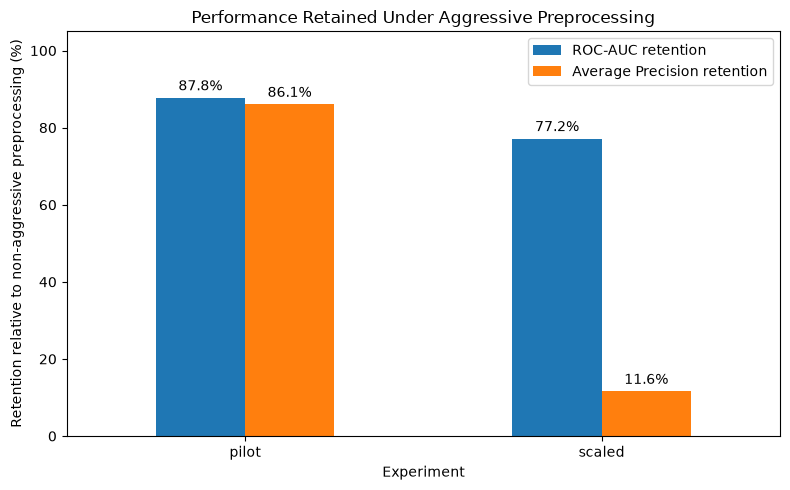


Saved: /workspaces/irp-disempowerment-nlp/results/figures/final_pilot_vs_scaled_preprocessing_retention.png

Retention values:
experiment  roc_auc_retention_pct  ap_retention_pct
     pilot                  87.76             86.06
    scaled                  77.18             11.60


In [6]:
# ------------------------------------------------------------
# Final synthesis figure:
# retention under aggressive preprocessing
# ------------------------------------------------------------

import matplotlib.pyplot as plt


retention_plot_df = (
    pilot_vs_scaled_df[
        [
            "experiment",
            "nonaggressive_mean_roc_auc",
            "aggressive_mean_roc_auc",
            "nonaggressive_mean_ap",
            "aggressive_mean_ap",
        ]
    ]
    .copy()
)


retention_plot_df[
    "roc_auc_retention_pct"
] = (
    retention_plot_df[
        "aggressive_mean_roc_auc"
    ]
    /
    retention_plot_df[
        "nonaggressive_mean_roc_auc"
    ]
    * 100
)


retention_plot_df[
    "ap_retention_pct"
] = (
    retention_plot_df[
        "aggressive_mean_ap"
    ]
    /
    retention_plot_df[
        "nonaggressive_mean_ap"
    ]
    * 100
)


plot_df = retention_plot_df[
    [
        "experiment",
        "roc_auc_retention_pct",
        "ap_retention_pct",
    ]
].set_index(
    "experiment"
)


ax = plot_df.plot(
    kind="bar",
    figsize=(8, 5),
)


ax.set_title(
    "Performance Retained Under Aggressive Preprocessing"
)

ax.set_xlabel(
    "Experiment"
)

ax.set_ylabel(
    "Retention relative to non-aggressive preprocessing (%)"
)

ax.set_ylim(
    0,
    105,
)

ax.legend(
    [
        "ROC-AUC retention",
        "Average Precision retention",
    ]
)

ax.tick_params(
    axis="x",
    rotation=0,
)


for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )


plt.tight_layout()


final_synthesis_figure_path = (
    RESULTS_FIGURE_DIR
    / "final_pilot_vs_scaled_preprocessing_retention.png"
)


plt.savefig(
    final_synthesis_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "\nSaved:",
    final_synthesis_figure_path,
)


print(
    "\nRetention values:"
)

print(
    retention_plot_df[
        [
            "experiment",
            "roc_auc_retention_pct",
            "ap_retention_pct",
        ]
    ]
    .round(2)
    .to_string(
        index=False
    )
)

## Pilot-to-Scaled Replication

The scaled experiment reproduces the main qualitative pattern observed in the pilot: aggressive preprocessing reduces classifier ranking performance relative to the non-aggressive preprocessing configurations.

Clean mean-fold ROC-AUC remained similar across the two experiments, with 0.8670 in the pilot and 0.8729 in the scaled experiment. This suggests that the baseline classifier retained broadly comparable ranking discrimination when the experiment was expanded.

However, the effect of aggressive preprocessing became substantially stronger at scale. In the pilot, aggressive preprocessing retained 87.8% of the non-aggressive ROC-AUC and 86.1% of the non-aggressive Average Precision. In the scaled experiment, these retention values fell to 77.2% and 11.6%, respectively.

The absolute Average Precision values should not be compared directly across the pilot and scaled experiments because the positive prevalence differs substantially between them (6.0% in the pilot versus approximately 1.0% in the scaled dataset). The within-experiment retention values are therefore more informative for assessing the effect of preprocessing.

Overall, the scaled experiment strengthens the pilot finding that aggressive text cleaning can remove information that is useful for ranking disempowerment-associated examples. The effect is particularly pronounced for Average Precision in the more imbalanced scaled setting.

## Technical Conclusions by Research Question

### RQ1 — Effect of preprocessing on classifier robustness

The scaled experiment indicates that preprocessing choice has a substantial effect on classifier robustness. The `none`, `minimal`, and `noise_aware` configurations produced broadly similar ranking performance, with a mean-fold ROC-AUC of approximately 0.87 across the non-aggressive configurations.

In contrast, `aggressive` preprocessing reduced mean-fold ROC-AUC to approximately 0.67. Relative to the non-aggressive configurations, aggressive preprocessing produced a mean ROC-AUC reduction of approximately 0.20 and retained only 11.6% of non-aggressive mean-fold Average Precision.

The results therefore indicate that limited or noise-aware cleaning can preserve useful classification signal, whereas aggressive text normalization can remove information that contributes materially to ranking positive examples.

### RQ2 — Noise and preprocessing combinations producing the largest changes

Synthetic textual noise alone produced comparatively modest changes in classifier ranking performance. With no preprocessing applied, the mixed-noise condition produced the lowest pooled ranking performance among the noise-only conditions, with ROC-AUC of 0.8520 and Average Precision of 0.1119, compared with clean values of 0.8628 and 0.1233.

The largest performance changes occurred when noisy inputs were combined with aggressive preprocessing rather than from noise alone. The lowest observed overall condition was `whitespace + aggressive`, with pooled ROC-AUC of 0.6467 and Average Precision of 0.0163.

This suggests that, within the tested noise model, preprocessing severity had a greater influence on robustness than the synthetic noise perturbations themselves.

### RQ3 — Preservation and loss of linguistic cues

The cue-retention analysis provides evidence that aggressive preprocessing removes linguistic constructions that contribute to the classifier's representation of directive advice.

Across directive-positive examples containing the tracked constructions `you should`, `you must`, `you need to`, or `you have to`, non-aggressive preprocessing retained at least one tracked cue in approximately 97–98% of evaluated rows. Aggressive preprocessing retained these tracked cues in 0% of evaluated rows.

This linguistic loss corresponded with a substantial change in classifier decision scores. Across positive examples, aggressive preprocessing produced a mean score shift of approximately -0.1973, while its mean absolute score change was approximately 20.17 times greater than under the non-aggressive configurations.

These results provide a concrete mechanism connecting preprocessing to reduced classifier robustness: aggressive normalization can remove modal and subject constructions while retaining much of the surrounding lexical content, thereby weakening features associated with the positive class.

### Interpretation boundaries

These conclusions concern **ranking robustness**, rather than successful hard-threshold classification. At the default `LinearSVC` decision threshold, the scaled model predicted no positive examples, so precision, recall, and F1 were all zero. ROC-AUC, Average Precision, decision-score sensitivity, and cue-retention diagnostics therefore provide the more informative evidence for this experiment.

The final scaled target should also be interpreted as an **audit-corrected weak-label target**, not exhaustive human-annotated ground truth. Only a deterministic sample of weak-negative examples was manually audited.

Finally, the RQ3 cue analysis is primarily evidence about **directive advice**. The audit-corrected scaled target contained insufficient examples of sycophantic validation and overconfident judgement to support equivalent category-specific conclusions for those patterns.

In [7]:
# ------------------------------------------------------------
# Final technical artefact integrity check
# ------------------------------------------------------------

expected_core_tables = [
    "pilot_classification_metrics.csv",
    "pilot_ranking_summary.csv",
    "pilot_score_shift_summary.csv",
    "scaled_fold_condition_metrics.csv",
    "scaled_oof_predictions_52256.csv",
    "scaled_robustness_summary_32_conditions.csv",
    "scaled_preprocess_effect_summary.csv",
    "scaled_positive_score_shifts.csv",
    "scaled_directive_cue_retention_summary.csv",
    "final_pilot_vs_scaled_comparison.csv",
    "final_research_question_synthesis.csv",
]

expected_core_figures = [
    "pilot_roc_auc_robustness.png",
    "pilot_average_precision_robustness.png",
    "pilot_positive_score_shift.png",
    "scaled_roc_auc_robustness.png",
    "scaled_average_precision_robustness.png",
    "scaled_positive_score_shift.png",
    "scaled_directive_cue_retention.png",
    "final_pilot_vs_scaled_preprocessing_retention.png",
]


# ------------------------------------------------------------
# 1. File existence
# ------------------------------------------------------------

missing_tables = [
    name
    for name in expected_core_tables
    if not (
        RESULTS_TABLE_DIR / name
    ).exists()
]

missing_figures = [
    name
    for name in expected_core_figures
    if not (
        RESULTS_FIGURE_DIR / name
    ).exists()
]

assert not missing_tables, (
    f"Missing tables: {missing_tables}"
)

assert not missing_figures, (
    f"Missing figures: {missing_figures}"
)


# ------------------------------------------------------------
# 2. Expected scaled experiment dimensions
# ------------------------------------------------------------

scaled_oof_check = pd.read_csv(
    RESULTS_TABLE_DIR
    / "scaled_oof_predictions_52256.csv"
)

scaled_summary_check = pd.read_csv(
    RESULTS_TABLE_DIR
    / "scaled_robustness_summary_32_conditions.csv"
)

assert len(scaled_oof_check) == 52256
assert len(scaled_summary_check) == 32

assert (
    scaled_oof_check[
        "source_index"
    ].nunique()
    == 1633
)

assert (
    scaled_summary_check[
        [
            "noise_condition",
            "preprocess_config",
        ]
    ]
    .drop_duplicates()
    .shape[0]
    == 32
)


# ------------------------------------------------------------
# 3. Target and class counts
# ------------------------------------------------------------

clean_none_check = (
    scaled_summary_check[
        (
            scaled_summary_check[
                "noise_condition"
            ] == "clean"
        )
        &
        (
            scaled_summary_check[
                "preprocess_config"
            ] == "none"
        )
    ]
    .iloc[0]
)

assert int(
    clean_none_check["n"]
) == 1633

assert int(
    clean_none_check["positives"]
) == 17

assert int(
    clean_none_check[
        "predicted_positives"
    ]
) == 0


# ------------------------------------------------------------
# 4. Headline scaled metrics
# ------------------------------------------------------------

assert np.isclose(
    clean_none_check[
        "pooled_roc_auc"
    ],
    0.862806,
    atol=1e-6,
)

assert np.isclose(
    clean_none_check[
        "pooled_average_precision"
    ],
    0.123340,
    atol=1e-6,
)

assert np.isclose(
    clean_none_check[
        "mean_fold_roc_auc"
    ],
    0.872921,
    atol=1e-6,
)


# ------------------------------------------------------------
# 5. Aggressive preprocessing mechanism
# ------------------------------------------------------------

aggressive_cue_check = (
    scaled_cue_summary_df[
        scaled_cue_summary_df[
            "preprocess_config"
        ] == "aggressive"
    ]
    .iloc[0]
)

assert np.isclose(
    aggressive_cue_check[
        "any_cue_retention_pct"
    ],
    0.0,
)

assert np.isclose(
    aggressive_cue_check[
        "all_cue_retention_pct"
    ],
    0.0,
)


# ------------------------------------------------------------
# 6. Final synthesis outputs
# ------------------------------------------------------------

assert len(
    pilot_vs_scaled_df
) == 2

assert len(
    rq_synthesis_df
) == 3

assert set(
    rq_synthesis_df[
        "research_question"
    ]
) == {
    "RQ1",
    "RQ2",
    "RQ3",
}


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("=" * 80)
print("FINAL TECHNICAL ARTEFACT INTEGRITY CHECK")
print("=" * 80)

print(
    f"Core tables present: "
    f"{len(expected_core_tables)}/{len(expected_core_tables)}"
)

print(
    f"Core figures present: "
    f"{len(expected_core_figures)}/{len(expected_core_figures)}"
)

print(
    "Scaled OOF rows:",
    len(scaled_oof_check),
)

print(
    "Scaled unique sources:",
    scaled_oof_check[
        "source_index"
    ].nunique(),
)

print(
    "Scaled conditions:",
    len(scaled_summary_check),
)

print(
    "Scaled positives:",
    int(
        clean_none_check[
            "positives"
        ]
    ),
)

print(
    "Clean pooled ROC-AUC:",
    round(
        clean_none_check[
            "pooled_roc_auc"
        ],
        4,
    ),
)

print(
    "Clean pooled AP:",
    round(
        clean_none_check[
            "pooled_average_precision"
        ],
        4,
    ),
)

print(
    "Clean mean-fold ROC-AUC:",
    round(
        clean_none_check[
            "mean_fold_roc_auc"
        ],
        4,
    ),
)

print(
    "Aggressive cue retention:",
    f"{aggressive_cue_check['any_cue_retention_pct']:.1f}%",
)

print()
print(
    "NOTEBOOK 07 FINAL INTEGRITY CHECK PASSED."
)

FINAL TECHNICAL ARTEFACT INTEGRITY CHECK
Core tables present: 11/11
Core figures present: 8/8
Scaled OOF rows: 52256
Scaled unique sources: 1633
Scaled conditions: 32
Scaled positives: 17
Clean pooled ROC-AUC: 0.8628
Clean pooled AP: 0.1233
Clean mean-fold ROC-AUC: 0.8729
Aggressive cue retention: 0.0%

NOTEBOOK 07 FINAL INTEGRITY CHECK PASSED.
